In [1]:
%pip install numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


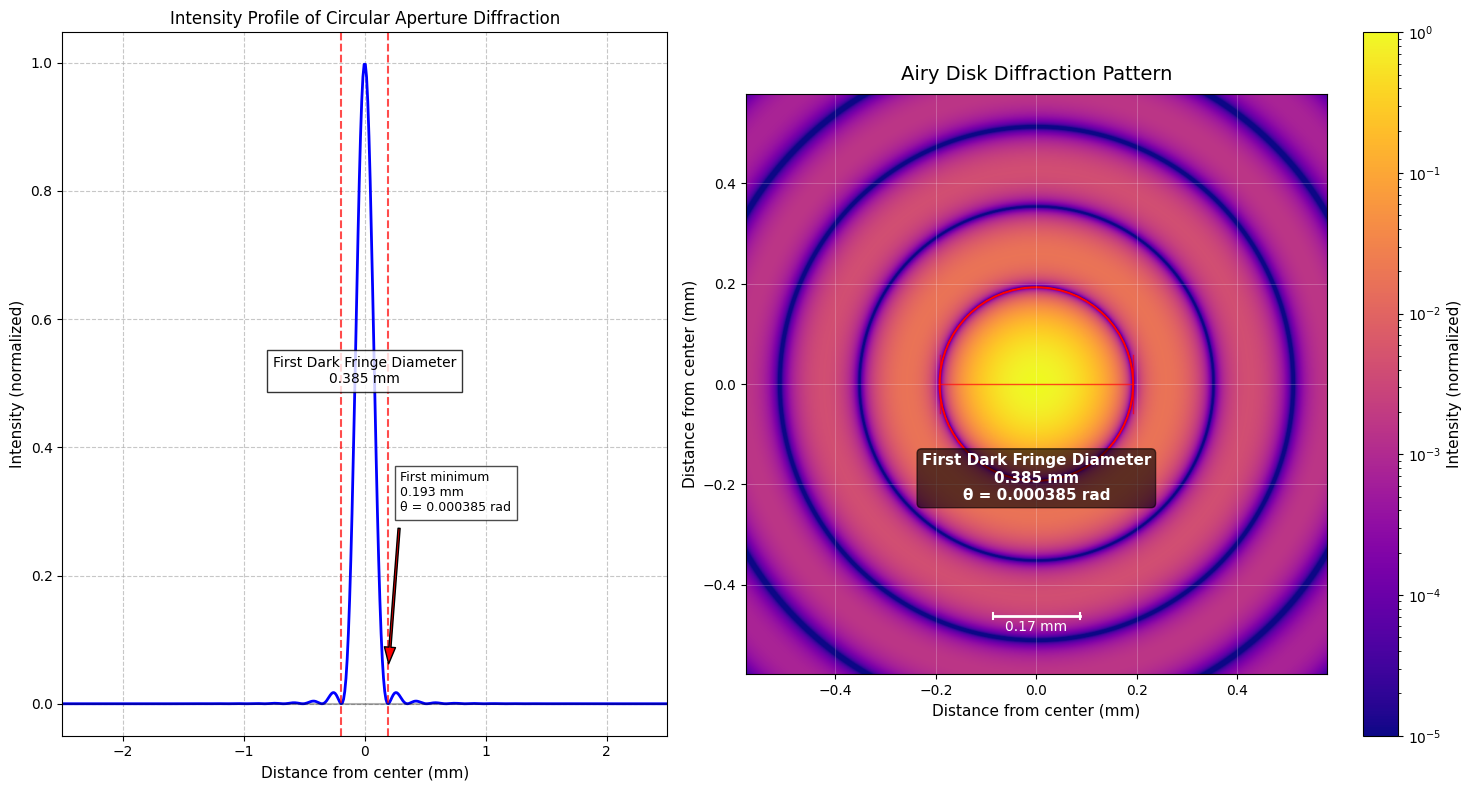

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1
from matplotlib.patches import Circle
from matplotlib.colors import LogNorm
from matplotlib import gridspec

# TODO: RECHECK THIS LATER ON

# Parameters
wavelength = 632e-9  # Wavelength (632 nm - red light)
aperture_radius = 1e-3  # Radius of circular aperture (1 mm)
k = 2 * np.pi / wavelength  # Wave number
I0 = 1.0  # Maximum intensity
z = 0.5  # Distance to screen (1 meter)

# Calculate the theoretical Airy disk radius
airy_radius = 1.22 * wavelength * z / (2 * aperture_radius)  # in meters
airy_radius_mm = airy_radius * 1000  # in mm
airy_diameter_mm = 2 * airy_radius_mm  # Full diameter in mm

# First minimum position (first dark ring)
first_min = 3.8317 / (k * aperture_radius) * z * 1000  # in mm
first_min_diameter = 2 * first_min  # Full diameter in mm

# Calculate the angle in radians for the first minimum
sin_theta_first_min = first_min / 1000 / z  # Convert mm to meters first
theta_first_min = np.arcsin(sin_theta_first_min)  # in radians

# Alternative calculation directly from formula
theta_first_min_direct = np.arcsin(3.8317 / (k * aperture_radius))  # in radians

# Create figure with two subplots using gridspec for better control
fig = plt.figure(figsize=(15, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])
ax1 = plt.subplot(gs[0])  # For intensity plot against theta
ax2 = plt.subplot(gs[1])  # For 2D visualization

# SUBPLOT 1: INTENSITY vs THETA PLOT
# Create theta values (in radians)
theta_max = 0.01  # Maximum theta value (radians)
theta = np.linspace(-theta_max, theta_max, 1000)
intensity_profile = np.ones_like(theta)

# Calculate intensity for each theta
for i, t in enumerate(theta):
    sin_theta = np.sin(t)
    if abs(sin_theta) < 1e-10:
        intensity_profile[i] = I0
    else:
        argument = k * aperture_radius * sin_theta
        intensity_profile[i] = I0 * (2 * j1(argument) / argument)**2

# Convert theta to mm on screen for x-axis (using sin(theta) ≈ theta for small angles)
x_mm = theta * z * 1000

# Plot intensity vs position
ax1.plot(x_mm, intensity_profile, 'b-', linewidth=2)
ax1.set_xlabel('Distance from center (mm)', fontsize=11)
ax1.set_ylabel('Intensity (normalized)', fontsize=11)
ax1.set_title('Intensity Profile of Circular Aperture Diffraction', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)

# Set the x-axis range to ±2.5 mm as requested
ax1.set_xlim(-2.5, 2.5)

# Mark the first minimum (first dark fringe)
ax1.axvline(first_min, color='red', linestyle='--', alpha=0.7)
ax1.axvline(-first_min, color='red', linestyle='--', alpha=0.7)
ax1.axhline(0, color='k', linestyle='-', alpha=0.3)

# Add annotation for first minimum with angle in radians
ax1.annotate(f'First minimum\n{first_min:.3f} mm\nθ = {theta_first_min:.6f} rad', 
            xy=(first_min, 0.05), xytext=(first_min+0.1, 0.3),
            arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

# Add text for diameter
ax1.text(0, 0.5, f'First Dark Fringe Diameter\n{first_min_diameter:.3f} mm',
        ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

# SUBPLOT 2: 2D AIRY DISK PATTERN
# Calculate 2D intensity pattern
size = 800  # Higher resolution
extent_mm = 3 * airy_radius_mm
extent_m = extent_mm / 1000
x = np.linspace(-extent_m, extent_m, size)
y = np.linspace(-extent_m, extent_m, size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
sin_theta = R / z  # Small angle approximation

# Calculate intensity pattern
intensity = np.ones_like(R) * I0
mask = sin_theta > 1e-10
argument = k * aperture_radius * sin_theta[mask]
intensity[mask] = I0 * (2 * j1(argument) / argument)**2

# Plot 2D intensity pattern with enhanced aesthetics
im = ax2.imshow(intensity, extent=[-extent_mm, extent_mm, -extent_mm, extent_mm],
                cmap='plasma', norm=LogNorm(vmin=1e-5, vmax=I0))
ax2.set_xlabel('Distance from center (mm)', fontsize=11)
ax2.set_ylabel('Distance from center (mm)', fontsize=11)
ax2.set_title('Airy Disk Diffraction Pattern', fontsize=14, pad=10)

# Add enhanced grid
ax2.grid(color='white', linestyle='-', linewidth=0.5, alpha=0.3)

# Add technical drawing style dimension line for the first minimum diameter
# Horizontal dimension line
ax2.plot([-first_min, first_min], [0, 0], 'r-', lw=1, alpha=0.7)
# Vertical extension lines
ax2.plot([-first_min, -first_min], [-0.1*extent_mm, 0.1*extent_mm], 'r-', lw=1, alpha=0.7)
ax2.plot([first_min, first_min], [-0.1*extent_mm, 0.1*extent_mm], 'r-', lw=1, alpha=0.7)

# Add circle showing the first minimum (Airy disk boundary)
airy_circle = Circle((0, 0), first_min, fill=False, 
                     color='red', linestyle='-', linewidth=1.5)
ax2.add_patch(airy_circle)

# Technical dimension label with angle information
ax2.text(0, -first_min*1.2, 
        f"First Dark Fringe Diameter\n{first_min_diameter:.3f} mm\nθ = {theta_first_min:.6f} rad", 
        color='white', fontsize=11, ha='center', weight='bold',
        bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))

# Add enhanced colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Intensity (normalized)', fontsize=11)

# Add scale indicator with tick marks
scale_line_length = extent_mm * 0.3
ax2.plot([-scale_line_length/2, scale_line_length/2], 
         [-0.8*extent_mm, -0.8*extent_mm], 'w-', lw=2)
ax2.plot([-scale_line_length/2, -scale_line_length/2], 
         [-0.79*extent_mm, -0.81*extent_mm], 'w-', lw=1.5)
ax2.plot([scale_line_length/2, scale_line_length/2], 
         [-0.79*extent_mm, -0.81*extent_mm], 'w-', lw=1.5)
ax2.text(0, -0.85*extent_mm, 
         f"{scale_line_length:.2f} mm", 
         color='white', ha='center', fontsize=10)

plt.tight_layout()

plt.show()